In [ ]:
import os
import pandas as pd

ROOT = r"D:\Gi_project\data\train_and_validation_sets"

records = []

for label in sorted(os.listdir(ROOT)):
    class_dir = os.path.join(ROOT, label)
    if not os.path.isdir(class_dir):
        continue

    for img in os.listdir(class_dir):
        if img.lower().endswith((".jpg", ".png", ".jpeg", ".bmp")):
            records.append({
                "image_path": os.path.join(class_dir, img),
                "label": int(label.split()[1])
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
df.head()


Total images: 9590


,image_path,label
0,D:\Gi_project\train_and_validation_sets\Mayo 0...,0
1,D:\Gi_project\train_and_validation_sets\Mayo 0...,0
2,D:\Gi_project\train_and_validation_sets\Mayo 0...,0
3,D:\Gi_project\train_and_validation_sets\Mayo 0...,0
4,D:\Gi_project\train_and_validation_sets\Mayo 0...,0


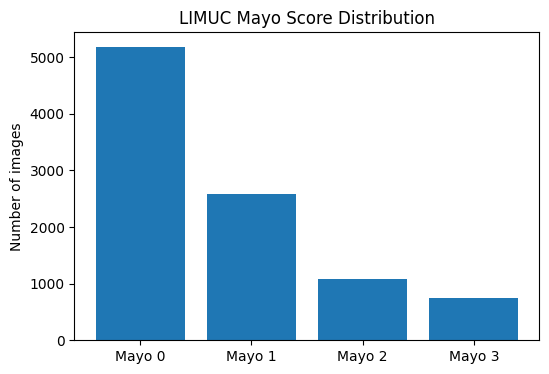

label
0    5180
1    2588
2    1077
3     745
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xticks([0,1,2,3], ['Mayo 0','Mayo 1','Mayo 2','Mayo 3'])
plt.ylabel("Number of images")
plt.title("LIMUC Mayo Score Distribution")
plt.show()

counts


In [3]:
(counts / sum(counts)) * 100 

label
0    54.014599
1    26.986444
2    11.230448
3     7.768509
Name: count, dtype: float64

In [4]:
from PIL import Image

img = Image.open(df.iloc[0].image_path)
print("Size:", img.size)
print("Mode:", img.mode)


Size: (352, 288)
Mode: RGB


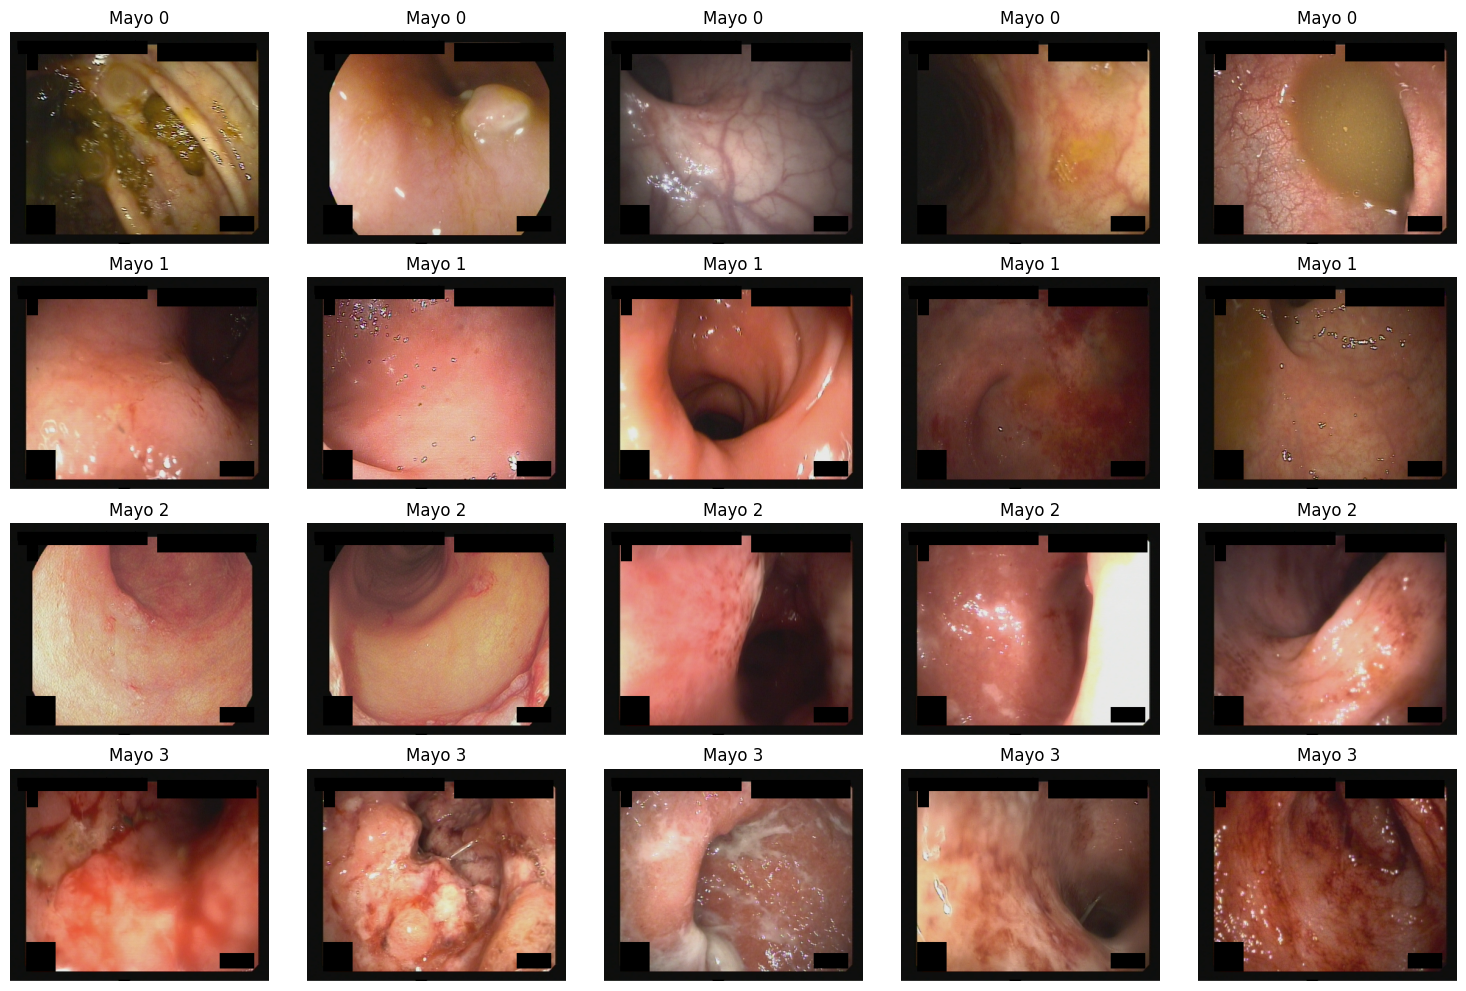

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for label in range(4):
    samples = df[df.label == label].sample(5)
    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.image_path)
        axes[label, i].imshow(img)
        axes[label, i].axis("off")
        axes[label, i].set_title(f"Mayo {label}")

plt.tight_layout()
plt.show()


okay the final intuition...
# LIMUC Dataset: Findings, Intuition, and Modeling Strategy

## 1. What We Observed (Empirical Findings)

### 1.1 Label–Image Mismatch at Frame Level

During qualitative inspection of the LIMUC dataset (organized purely as image folders by Mayo score), several inconsistencies became apparent:

* Images labeled **Mayo 0** sometimes exhibit mucus, bubbles, or mild erythema.
* Images labeled **Mayo 1** and **Mayo 2** often overlap visually, with no clear boundary.
* Some **Mayo 3** images show obvious ulceration or bleeding, while others resemble severe erythema closer to Mayo 2.

This indicates that LIMUC labels are **not strict frame-level annotations**.

### 1.2 Weak Supervision Nature of LIMUC

The observed inconsistencies are consistent with how LIMUC was constructed:

* Mayo scores are typically assigned at the **procedure or patient level** by clinicians.
* These scores are then **propagated to multiple frames**, including transitional or non-representative regions.
* As a result, frame-level labels are **weak, noisy, and fuzzy**.

This is not a flaw unique to LIMUC but a common characteristic of real-world medical imaging datasets.

### 1.3 Ordinal Structure of Mayo Scores

The Mayo Endoscopic Score is inherently **ordinal**:

```
Mayo 0 < Mayo 1 < Mayo 2 < Mayo 3
```

Misclassifying Mayo 2 as Mayo 3 is clinically less severe than misclassifying Mayo 2 as Mayo 0. However, standard multi-class classification treats all errors equally.

### 1.4 Clinical Risk Asymmetry

From a clinical perspective:

* **Active disease (Mayo 2–3)** must not be missed.
* A **false negative** (predicting remission when disease is active) is the most harmful error.
* A **false positive** (predicting active disease when in remission) is comparatively safer.

Therefore, recall (sensitivity) for active disease is more important than overall accuracy.

---

## 2. Core Intuition Derived from the Analysis

Based on the observations above, we arrived at the following key intuitions:

1. **Strict classification is inappropriate** for LIMUC due to fuzzy, weakly supervised labels.
2. The model should respect the **ordinal and continuous nature** of disease severity.
3. Decisions should be **risk-aware**, prioritizing detection of active disease over strict label matching.
4. The modeling approach should explicitly accommodate **uncertainty and proximity** between adjacent Mayo scores.

In short:

> *Because the data is fuzzy and the disease progression is continuous, the model should also be fuzzy-aware and ordinal, rather than rigid and categorical.*

---

## 3. Reformulating the Problem

### 3.1 Clinically Aligned Binary Abstraction

We leverage a clinically accepted abstraction:

* **Remission**: Mayo 0–1
* **Active disease**: Mayo 2–3

This binary split:

* Has higher inter-observer agreement
* Reduces label noise
* Aligns with clinical trial endpoints

### 3.2 Ordinal Severity Within Each State

While the binary decision answers *whether* inflammation is present, it does not capture *how severe* it is. Therefore, severity estimation remains important:

* Within remission: Mayo 0 vs Mayo 1
* Within active disease: Mayo 2 vs Mayo 3

This naturally leads to an **ordinal or ranking-based formulation**.

---

## 4. Proposed Modeling Strategy

### 4.1 Hierarchical and Ordinal Learning

We propose a hierarchical approach with shared visual representations:

1. **Binary Head (Primary, Robust Task)**

   * Predicts remission vs active disease
   * Optimized for high recall (low false negatives)

2. **Ordinal Severity Head (Secondary, Fine-Grained Task)**

   * Predicts disease severity as an ordered quantity
   * Trained using ordinal or ranking-aware loss functions

### 4.2 Proximity-Based Final Decision

Instead of hard class assignments, the model outputs:

* A probability of active disease
* A continuous or ordinal severity score

Final Mayo classification is determined based on **proximity to ordinal thresholds**, constrained by the binary decision. This allows:

* Soft boundaries
* Reduced penalty for near-miss errors
* Explicit uncertainty handling

---

## 5. Loss Functions and Optimization Objectives

To reflect clinical priorities and label fuzziness:

* Binary loss weighted to **penalize false negatives more heavily**
* Ordinal loss (e.g., cumulative link / QWK-based) to preserve severity ordering
* Optional soft or fuzzy targets to encode label uncertainty

The combined objective encourages:

* High sensitivity for active disease
* Smooth severity estimation
* Robustness to weak supervision

---

## 6. Evaluation Philosophy

Standard accuracy is insufficient. Instead, evaluation emphasizes:

* **Recall (Sensitivity) for Active Disease**
* **False Negative Rate (FNR)**
* **F2-score** (recall-weighted)
* **Quadratic Weighted Kappa (QWK)** for ordinal agreement

This aligns model evaluation with real clinical risk.

---

## 7. Summary

* LIMUC labels are weakly supervised and visually fuzzy at the frame level.
* Mayo scoring is ordinal and clinically risk-asymmetric.
* False negatives for active disease are the most critical error.
* A hierarchical, ordinal, and fuzzy-aware modeling approach is the most appropriate.
* Reformulating the task as **remission vs active + ordinal severity** is clinically defensible and methodologically sound.

This framework ensures that modeling decisions are guided by both medical reality and machine learning principles, rather than rigid label assumptions.


To capture both fine-grained mucosal textures and global inflammatory patterns under weak supervision, we adopt a hybrid EFFResNet-ViT architecture that fuses convolutional and transformer representations. This design enables robust feature learning while supporting ordinal severity estimation and visual explainability.